In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 8000

df = pd.DataFrame({
    "customer_id": range(n),

    # Income (NBFC reality: noisy & sometimes overstated)
    "income": np.random.lognormal(mean=10, sigma=0.7, size=n),

    # Bureau score (not clean predictor)
    "bureau_score": np.clip(np.random.normal(680, 90, n), 300, 900),

    # Loan amount (loosely tied to income, not strict)
    "loan_amount": np.random.lognormal(mean=11, sigma=0.6, size=n),

    # Utilization (behavioral, important but unstable)
    "utilization": np.clip(np.random.beta(2, 3, n), 0, 1),

    # Vintage (origination cohort → macro effect)
    "origination_month": np.random.randint(1, 13, n)
})

In [2]:
mask = np.random.rand(n) < 0.25
df.loc[mask, "income"] *= np.random.uniform(1.2, 2.5, mask.sum())

In [3]:
mask = np.random.rand(n) < 0.20
df.loc[mask, "bureau_score"] = np.random.uniform(500, 750, mask.sum())

In [4]:
mask = np.random.rand(n) < 0.15
df.loc[mask, "utilization"] = np.random.uniform(0.85, 1.0, mask.sum())

In [5]:
df["risk_score"] = (
    -0.000002 * df["income"] +        # weak signal
    -0.002 * df["bureau_score"] +     # weak signal
    0.000003 * df["loan_amount"] +
    1.8 * df["utilization"] +
    
    # Vintage risk (macro effect)
    0.3 * (df["origination_month"].isin([6,7,8]).astype(int)) +

    # BIG noise → realism
    np.random.normal(0, 1.2, n)
)

In [6]:
base_hazard = np.exp(df["risk_score"])

random_shock = np.random.uniform(0.5, 1.5, n)

df["true_time_to_event"] = np.random.exponential(
    scale=1 / (base_hazard * random_shock)
)

In [7]:
mask = np.random.rand(n) < 0.35
df.loc[mask, "true_time_to_event"] = df.loc[mask, "true_time_to_event"] + 50

In [8]:
max_observation_time = 18

df["tenure"] = np.minimum(df["true_time_to_event"], max_observation_time)
df["event"] = (df["true_time_to_event"] <= max_observation_time).astype(int)

In [9]:
# EMI (approx)
df["emi"] = df["loan_amount"] / np.random.randint(12, 36, n)

# Payment ratio (noisy behavioral proxy)
df["payment_ratio"] = np.clip(
    np.random.normal(0.6, 0.25, n) - 0.3 * df["utilization"],
    0, 1
)

# DPD proxy (derived noisy behavior)
df["dpd_flag"] = (
    (df["payment_ratio"] < 0.4) &
    (np.random.rand(n) < 0.6)
).astype(int)

In [10]:
print("Default Rate:", df["event"].mean())
print(df["tenure"].describe())

Default Rate: 0.637
count    8000.000000
mean        7.858105
std         8.048211
min         0.000214
25%         0.474383
50%         2.927284
75%        18.000000
max        18.000000
Name: tenure, dtype: float64


In [11]:
df.head()

,customer_id,income,bureau_score,loan_amount,utilization,origination_month,risk_score,true_time_to_event,tenure,event,emi,payment_ratio,dpd_flag
0,0,31185.231336,677.027726,101476.687941,0.361540,3,-1.554981,3.132794,3.132794,1,3624.167426,0.677530,0
1,1,19994.549476,634.671477,61303.089434,0.997853,9,-0.315618,52.215442,18.000000,0,4086.872629,0.280357,0
2,2,69172.302190,664.486254,34634.469434,0.498852,6,0.583145,0.500989,0.500989,1,1282.758127,0.547614,0
3,3,129062.688584,709.398985,45365.197178,0.297742,11,-1.322072,3.146568,3.146568,1,2160.247485,0.302317,1
4,4,18696.519036,795.007099,73549.364048,0.942834,8,-1.443728,5.052614,5.052614,1,5253.526003,0.082307,0


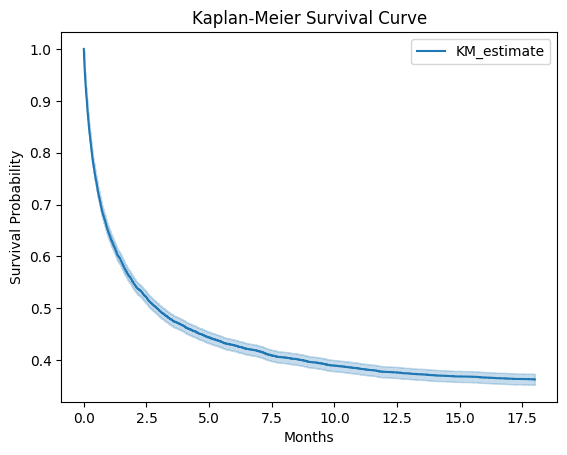

In [16]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df["tenure"],
    event_observed=df["event"]
)

kmf.plot()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.show()